# Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

# Load data

In [3]:
from eyewire2_functional_analysis import data_loader

data_folder = "../../../data/preprocessed-data"
morph_folder = "../../../data/morphological-data"

In [4]:
print(sorted(os.listdir(morph_folder)))

['Eyewire II Proofread Cells Master List - All Cells 2026-03-17.csv', 'roi_mapping_2p_to_em.csv']


In [5]:
df_rois, df_fields, df_outline = data_loader.load_all_dfs(data_folder)

df = data_loader.load_df_rois_morph(
    morph_folder=morph_folder,
    morph_spreadsheet_filename='Eyewire II Proofread Cells Master List - All Cells 2026-03-17.csv',
    nuc_col_master='Final NucID',
    seg_col_master=(
        'Updated Seg ID\n(Feb 04, 2026)\nIF YOU UPDATE THIS COLUMN, ALSO UPDATE Final SegID!',
        'Updated Seg ID (Sept 2)',
        'Final SegID'),
    df_rois=df_rois,
)

In [6]:
[c for c in df.columns if 'ID' in c]

['Final NucID',
 'Box ID',
 'Final SegID',
 'Updated Nuc ID (Sept 2)',
 'Updated Seg ID (Sept 2)',
 'Cell Requires Review (DO NOT use Updated IDs for those cells)',
 'Updated Nuc ID\n(Feb 04, 2026)\nIF YOU UPDATE THIS COLUMN, ALSO UPDATE Final NucID!',
 'Updated Seg ID\n(Feb 04, 2026)\nIF YOU UPDATE THIS COLUMN, ALSO UPDATE Final SegID!',
 "Cell Requires Review \n(Feb 04, 2026)\n(don't use Updated IDs if this is True)\nDon't change to FALSE manually, setting to TRUE manually is ok",
 'Latest SegID']

### Inspect dataframe

In [7]:
### each row is a cell
df

,Final NucID,Index,Box ID,Box Rank,Nuc Coords,Soma Coords,Cell Type (deprecated),611 Proofreader,Proofreader 2,Status,...,supergroup,prob_cluster,prob_group,prob_supergroup,prob_class,probs_per_cluster,seg_id,nuc_id,qfilt,Latest SegID
0,720575940554861467,A43,NaN,NaN,NaN,NaN,ON-SAC,Althea Lou,NaN,Can't Complete,...,Slow ON,0.789362,0.789362,0.874497,0.929468,"[0.001688096601444819, 0.0016375959626820189, ...",720575940557124706,720575940554861467,True,720575940557124706
1,720575940572981949,B37,NaN,NaN,"36716, 21255, 680","36746, 21000, 680",ON-SAC,Nseraf,NaN,Complete,...,dAC,0.567364,0.771353,0.884248,0.884248,"[0.0028011801453518823, 0.0024908340206640815,...",720575940557921829,720575940572981949,True,720575940557921829
2,720575940577751704,D1,NaN,NaN,"32653.0,23923.0,553.0","32653.0,23923.0,583.0",NaN,Elison,Greg,Complete,...,ON-OFF,0.804667,0.819760,0.832646,0.913740,"[0.0020822615335256726, 0.0032838992937911002,...",720575940550529705,720575940577751704,False,720575940568899103
3,720575940534317101,D2,NaN,NaN,"33159.0,22959.0,606.0","33159.0,22959.0,661.0",NaN,Juliane,Jonathan\nChristine Joy,Complete,...,dAC,0.605752,0.615440,0.702638,0.702638,"[0.003336756586838654, 0.008818983121221289, 0...",720575940568652126,720575940534317101,True,720575940569631083
4,720575940554891618,D3,NaN,NaN,"33787.0,21853.0,597.0","33787.0,21853.0,677.0",ON-SAC,Nseraf,Juliane\nGlenda,Complete,...,dAC,0.772927,0.790771,0.927322,0.927322,"[0.0017071109567420337, 0.0016375104799094017,...",720575940572885792,720575940554891618,True,720575940574791163
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
374,720575940561162052,D369,NaN,NaN,"51146.0,19735.0,1003.0","51229.0,19465.0,983.0",NaN,Glenda,NaN,Complete,...,dAC,0.760361,0.795951,0.924808,0.924808,"[0.0017427828931796876, 0.0016094993655214065,...",720575940558956177,720575940561162052,True,720575940578408489
375,720575940569319349,D370,NaN,NaN,"51502.0,19497.0,965.0","51431.0,19511.0,994.0",NaN,Glenda,NaN,Complete,...,Slow ON,0.657267,0.657267,0.912382,0.957618,"[0.0013527515503129882, 0.001395631364001735, ...",720575940563588453,720575940569319349,True,720575940563588453
376,720575940581392083,E177,NaN,NaN,"39118, 24485, 623","39245, 24635, 637",SAC,Cj,Charm,Complete,...,dAC,0.789306,0.878349,0.927613,0.927613,"[0.001743295222772673, 0.0016255236446178986, ...",720575940556421607,720575940581392083,True,720575940556421607
377,720575940579434707,D21,NaN,NaN,"33645.0,24480.0,456.0","33645.0,24480.0,491.0",NaN,Enriq,NaN,Complete,...,dAC,0.665092,0.682904,0.903983,0.903983,"[0.00190230492020636, 0.0019956140038342837, 0...",720575940559774600,720575940579434707,True,720575940559774600


In [8]:
### raw and preprocessed ("pp") traces for the chirp
df[['chirp_trace', 'chirp_trace_t0', 'chirp_trace_dt',
    'chirp_pp_trace', 'chirp_pp_trace_t0', 'chirp_pp_trace_dt', 
    'chirp_qidx',
    'chirp_pres_qidx', 
    'chirp_average_norm', 'chirp_average_dt',
    'chirp_snippets', 'chirp_snippets_t0', 'chirp_snippets_dt',
    'chirp_triggertimes_snippets']]

,chirp_trace,chirp_trace_t0,chirp_trace_dt,chirp_pp_trace,chirp_pp_trace_t0,chirp_pp_trace_dt,chirp_qidx,chirp_pres_qidx,chirp_average_norm,chirp_average_dt,chirp_snippets,chirp_snippets_t0,chirp_snippets_dt,chirp_triggertimes_snippets
0,"[11045.73076923077, 11036.73076923077, 11042.4...",0.044,0.128,"[1.1028164625167847, -0.33053940534591675, 0.5...",0.044,0.128,0.648772,0.666667,"[0.019929855259703647, 0.01644467734477757, 0....",0.016667,"[[-0.4457029104232788, 0.02754068374633789, 0....","[14.508000000000001, 47.532, 80.556, 113.58, 1...",0.128,"[[14.592000007629395, 47.619998931884766, 80.6..."
1,"[11804.925925925925, 11796.222222222223, 11812...",0.048,0.128,"[1.267539143562317, 0.41600507497787476, 1.963...",0.048,0.128,0.708350,0.454545,"[0.022869726303574624, 0.026294971251600602, 0...",0.016667,"[[-0.3411095440387726, -0.10755652189254761, -...","[11.952, 44.976000000000006, 78.0, 111.024, 14...",0.128,"[[11.982000350952148, 45.00600051879883, 78.03..."
2,"[10971.722222222223, 11032.333333333334, 11030...",0.004,0.128,"[-0.42704951763153076, -0.4251518249511719, -1...",0.004,0.128,0.240006,0.454545,"[-0.05811083179500478, -0.03405306415923126, -...",0.016667,"[[-0.3546017110347748, -0.29192373156547546, 0...","[11.908, 44.932, 77.956, 110.98, 144.004]",0.128,"[[11.982000350952148, 45.00600051879883, 78.03..."
3,"[10972.0625, 11107.4375, 11105.6875, 11106.312...",0.004,0.128,"[0.9237510561943054, 0.9281723499298096, 0.426...",0.004,0.128,0.245319,0.454545,"[0.0831090088387518, 0.07818372384234501, 0.07...",0.016667,"[[0.5335551500320435, 0.10151416063308716, -1....","[11.908, 44.932, 77.956, 110.98, 144.004]",0.128,"[[11.982000350952148, 45.00600051879883, 78.03..."
4,"[10971.75, 11179.25, 11165.5, 11165.7916666666...",0.004,0.128,"[0.7143154144287109, 0.7154080271720886, -2.08...",0.004,0.128,0.576327,0.454545,"[0.014870134226319399, 0.03364100145931817, 0....",0.016667,"[[-1.1198689937591553, -1.4662977457046509, 0....","[11.908, 44.932, 77.956, 110.98, 144.004]",0.128,"[[11.982000350952148, 45.00600051879883, 78.03..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
374,"[11022.714285714286, 11022.5, 11016.0714285714...",0.122,0.128,"[0.7814661264419556, 0.7283658385276794, -1.06...",0.122,0.128,0.395940,0.666667,"[0.15605477566539255, 0.13365788418144012, 0.1...",0.016667,"[[1.8387330770492554, 0.032195888459682465, -1...","[14.586, 47.61, 80.634, 113.658, 146.682000000...",0.128,"[[14.592000007629395, 47.619998931884766, 80.6..."
375,"[11123.42857142857, 11108.0, 11114.0, 11111.07...",0.125,0.128,"[1.2381796836853027, -0.05768724903464317, 0.4...",0.125,0.128,0.724089,0.666667,"[-0.11645501699751315, -0.11536026590374442, -...",0.016667,"[[0.23684239387512207, -0.9709717035293579, 0....","[14.589, 47.613, 80.637, 113.661, 146.685]",0.128,"[[14.592000007629395, 47.619998931884766, 80.6..."
376,"[11122.4375, 11130.9375, 11128.375, 11130.1875...",0.124,0.128,"[-0.16375693678855896, 1.4957798719406128, 0.9...",0.124,0.128,0.518719,0.454545,"[0.030003207373619244, 0.036348777076341, 0.04...",0.016667,"[[-1.2180358171463013, -0.7094292640686035, 1....","[11.9, 44.92400000000001, 77.948, 110.972, 143...",0.128,"[[11.982000350952148, 45.00600051879883, 78.03..."
377,"[11133.923076923076, 11130.615384615385, 11123...",0.028,0.128,"[0.9585143327713013, 0.334817111492157, -1.049...",0.028,0.128,0.611289,0.454545,"[-0.1252157567179411, -0.11031525724954352, -0...",0.016667,"[[-2.2483644485473633, -1.5242732763290405, -0...","[11.932, 44.956, 77.98, 111.004, 144.028]",0.128,"[[11.982000350952148, 45.00600051879883, 78.03..."


In [9]:
df['chirp_trace']

0      [11045.73076923077, 11036.73076923077, 11042.4...
1      [11804.925925925925, 11796.222222222223, 11812...
2      [10971.722222222223, 11032.333333333334, 11030...
3      [10972.0625, 11107.4375, 11105.6875, 11106.312...
4      [10971.75, 11179.25, 11165.5, 11165.7916666666...
                             ...                        
374    [11022.714285714286, 11022.5, 11016.0714285714...
375    [11123.42857142857, 11108.0, 11114.0, 11111.07...
376    [11122.4375, 11130.9375, 11128.375, 11130.1875...
377    [11133.923076923076, 11130.615384615385, 11123...
378    [11043.833333333334, 11040.708333333334, 11043...
Name: chirp_trace, Length: 379, dtype: object

In [10]:
#raw trace for first cell
trace = df['chirp_trace'][0]
trace

array([11045.73076923, 11036.73076923, 11042.46153846, ...,
       11021.65384615, 11021.76923077, 11020.38461538], shape=(1415,))

In [11]:
#time delta between samples
dt = df['chirp_trace_dt'][0]
dt

np.float64(0.128)

In [12]:
# duration of all chirp recordings (seconds)
dt * len(trace)

np.float64(181.12)

In [13]:
raw_time = np.arange(0,stop=dt*len(trace),step=dt)

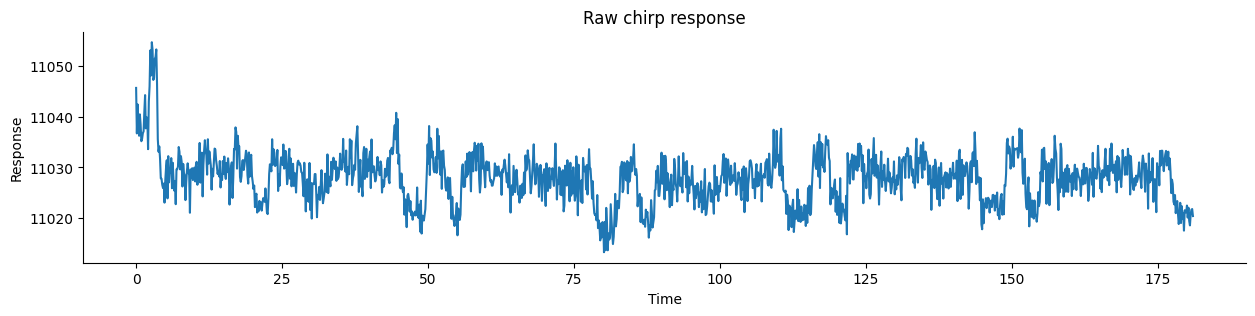

In [14]:
plt.figure(figsize=(15,3))
plt.plot(raw_time,trace)
plt.title('Raw chirp response')
plt.ylabel('Response')
plt.xlabel('Time')
sns.despine()

#### Looking at single trials

In [15]:
#raw trace cut into its five trials
trials = df['chirp_snippets'][0]
trials

array([[-0.44570291,  0.02754068,  0.65194756,  0.47460458, -0.29284382],
       [-0.02992407, -0.02754068,  0.16196167, -0.04299131,  0.08812743],
       [-0.18516821,  0.08770519, -0.69463277, -0.22360149,  0.09299251],
       ...,
       [-0.81058204,  0.22535676,  0.91527164,  0.37342259,  0.09993845],
       [-1.07741904, -0.6693356 , -0.09407771,  0.38096777, -0.46270156],
       [-0.88326383,  0.675569  ,  0.57672393,  0.17784712,  0.18756434]],
      shape=(259, 5))

In [16]:
#time delta between samples
dt_trial = df['chirp_snippets_dt'][0]
dt_trial

np.float64(0.128)

In [17]:
### duration of a single chirp trial
dt_trial * len(trials)

np.float64(33.152)

In [18]:
time = np.arange(0,stop=dt_trial*len(trials),step=dt_trial)

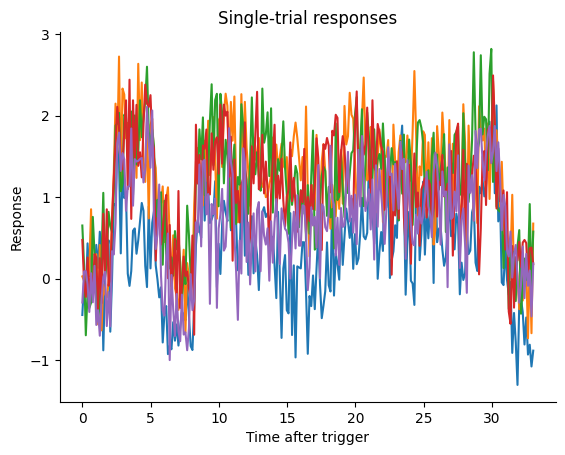

In [19]:
plt.plot(time,trials)
sns.despine()
plt.title('Single-trial responses')
plt.ylabel('Response')
plt.xlabel('Time after trigger')
plt.show()

### Averaged & normalized response

In [20]:
average = df['chirp_average_norm'][0]

In [21]:
avg_dt = df['chirp_average_dt'][0]

In [22]:
time_avg = np.arange(0,stop=avg_dt*len(average),step=avg_dt)

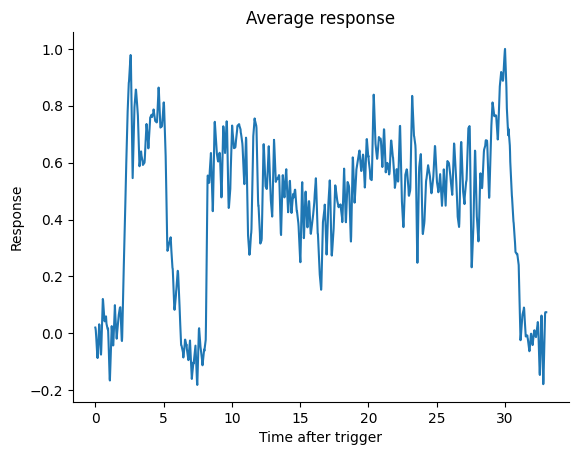

In [23]:
plt.plot(time_avg,average)
plt.title('Average response')
plt.ylabel('Response')
plt.xlabel('Time after trigger')
sns.despine()

# Plot data

In [24]:
row = df.iloc[0]

In [25]:
row.seg_id  # You can view this in neuroglancer

'720575940557124706'

In [26]:
chirp_time = np.arange(row.chirp_trace.size) * row.chirp_trace_dt + row.chirp_trace_t0
bar_time = np.arange(row.bar_trace.size) * row.bar_trace_dt + row.bar_trace_t0
mc_time = np.arange(row.mc_trace.size) * row.mc_trace_dt + row.mc_trace_t0

In [27]:
from eyewire2_functional_analysis.plot import plot_chirp, plot_bar

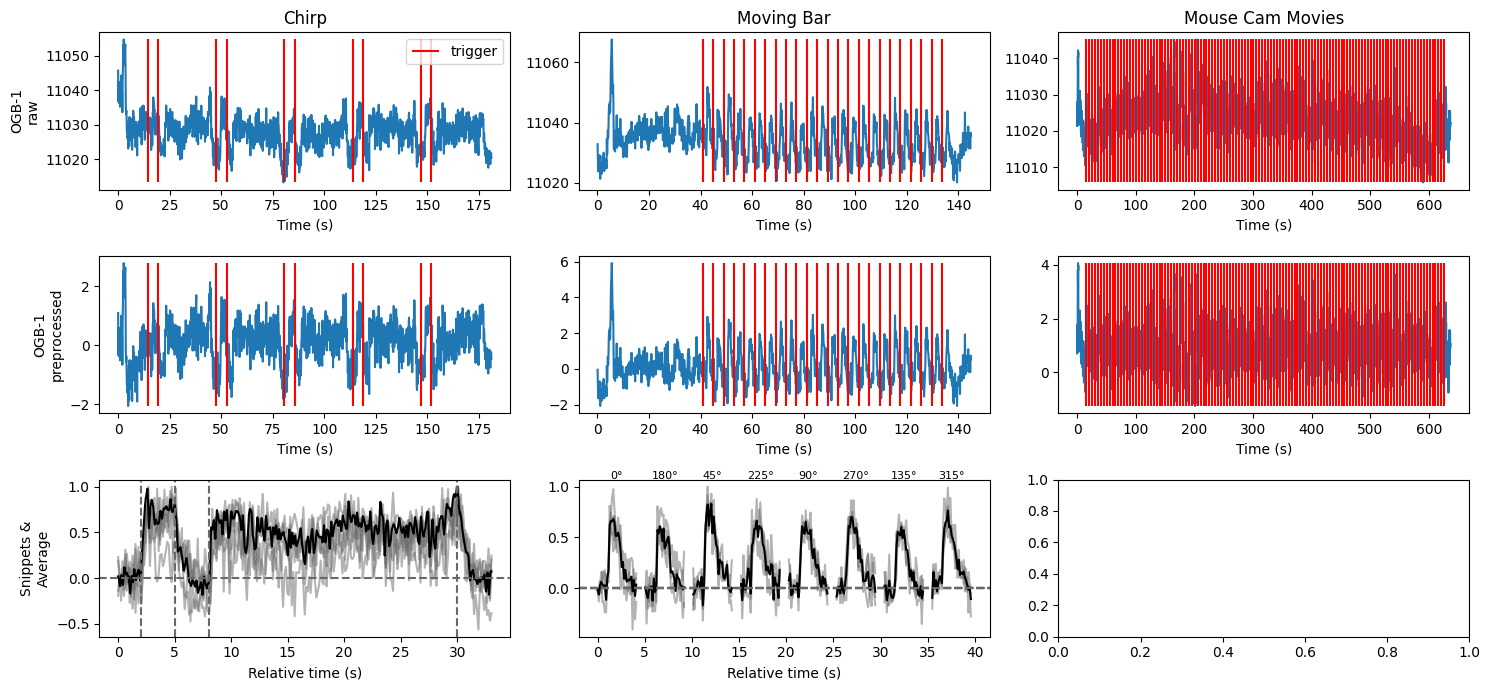

In [28]:
fig, axs = plt.subplots(3, 3, figsize=(15, 7))

# Raw
ax = axs[0, 0]
ax.plot(chirp_time, row.chirp_trace)
ax.vlines(row.chirp_triggertimes_snippets.flatten(), ymin=row.chirp_trace.min(), ymax=row.chirp_trace.max(), color='r',
          label='trigger')
ax.set(xlabel='Time (s)', ylabel='OGB-1\nraw', title='Chirp')
ax.legend(loc='upper right')

ax = axs[0, 1]
ax.plot(bar_time, row.bar_trace)
ax.vlines(row.bar_triggertimes_snippets.flatten(), ymin=row.bar_trace.min(), ymax=row.bar_trace.max(), color='r')
ax.set(xlabel='Time (s)', title='Moving Bar')

ax = axs[0, 2]
ax.plot(mc_time, row.mc_trace)
ax.vlines(row.mc_triggertimes.flatten(), ymin=row.mc_trace.min(), ymax=row.mc_trace.max(), color='r')
ax.set(xlabel='Time (s)', title='Mouse Cam Movies')

# Preprocessed
ax = axs[1, 0]
ax.plot(chirp_time, row.chirp_pp_trace)
ax.vlines(row.chirp_triggertimes_snippets.flatten(), ymin=row.chirp_pp_trace.min(), ymax=row.chirp_pp_trace.max(),
          color='r')
ax.set(xlabel='Time (s)', ylabel='OGB-1\npreprocessed')

ax = axs[1, 1]
ax.plot(bar_time, row.bar_pp_trace)
ax.vlines(row.bar_triggertimes_snippets.flatten(), ymin=row.bar_pp_trace.min(), ymax=row.bar_pp_trace.max(), color='r')
ax.set(xlabel='Time (s)')

ax = axs[1, 2]
ax.plot(mc_time, row.mc_pp_trace)
ax.vlines(row.mc_triggertimes.flatten(), ymin=row.mc_pp_trace.min(), ymax=row.mc_pp_trace.max(), color='r')
ax.set(xlabel='Time (s)')

# Average and repeats
ax = axs[2, 0]
plot_chirp(ax=ax, row=row, stimulus_ms=None, plot_hline=True, plot_vlines=True)
ax.set(xlabel='Relative time (s)', ylabel='Snippets &\nAverage')

ax = axs[2, 1]
plot_bar(ax=ax, row=row, annotate_dirs=True, annotate_symbols=False, ventral_up=True)
ax.set(xlabel='Relative time (s)')

plt.tight_layout()